In [9]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [10]:
df = pd.read_csv("../data/Samplesuperstore.csv")
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [11]:
print("Rows and Columns:" , df.shape)

Rows and Columns: (9994, 13)


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


In [13]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [14]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


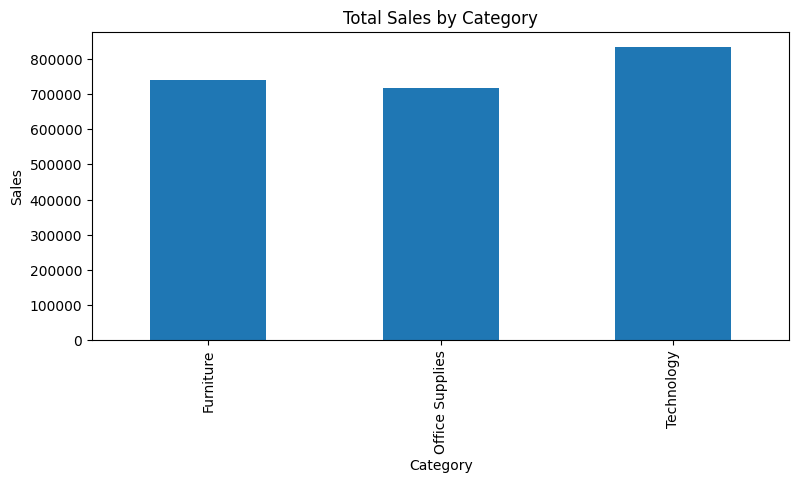

In [15]:
sales_by_category = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(9,4))
sales_by_category.plot(kind='bar')
plt.title('Total Sales by Category')
plt.ylabel('Sales')
plt.show()


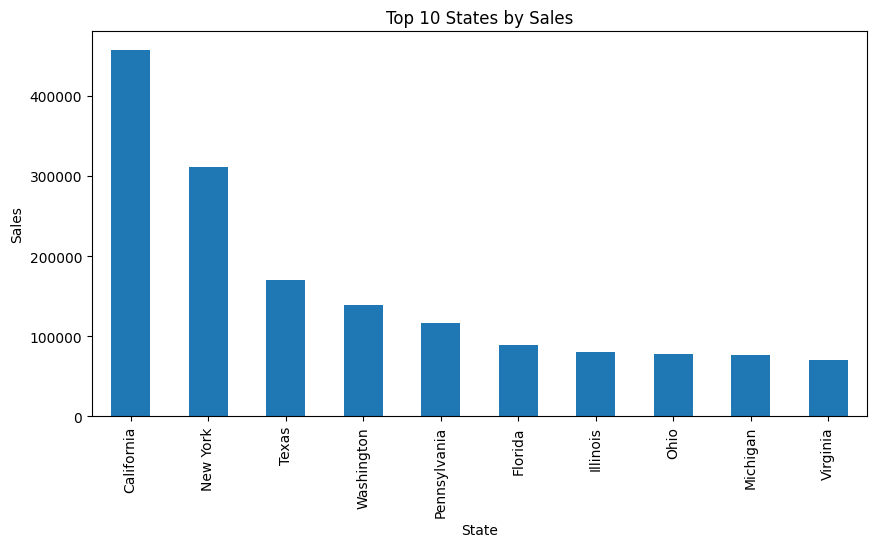

In [16]:
top_states=df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_states.plot(kind='bar')
plt.title('Top 10 States by Sales')
plt.ylabel('Sales')
plt.show()

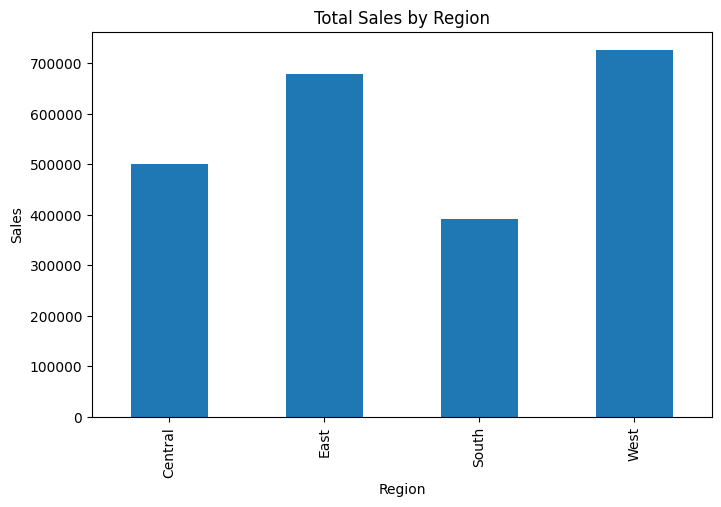

In [17]:
sales_by_region = df.groupby('Region')['Sales'].sum()
plt.figure(figsize=(8,5))
sales_by_region.plot(kind='bar')
plt.title('Total Sales by Region')
plt.ylabel('Sales')
plt.show()

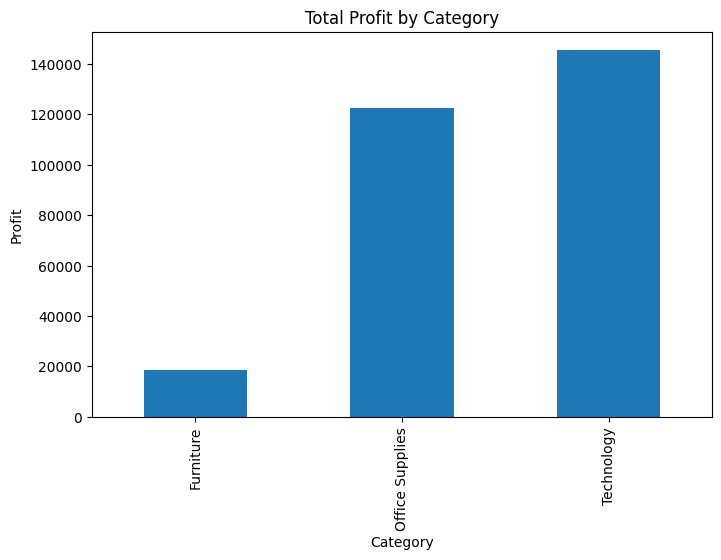

In [18]:
profit_by_category = df.groupby('Category')['Profit'].sum()
plt.figure(figsize=(8,5))
profit_by_category.plot(kind='bar')
plt.title('Total Profit by Category')
plt.ylabel('Profit')
plt.show()



In [19]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

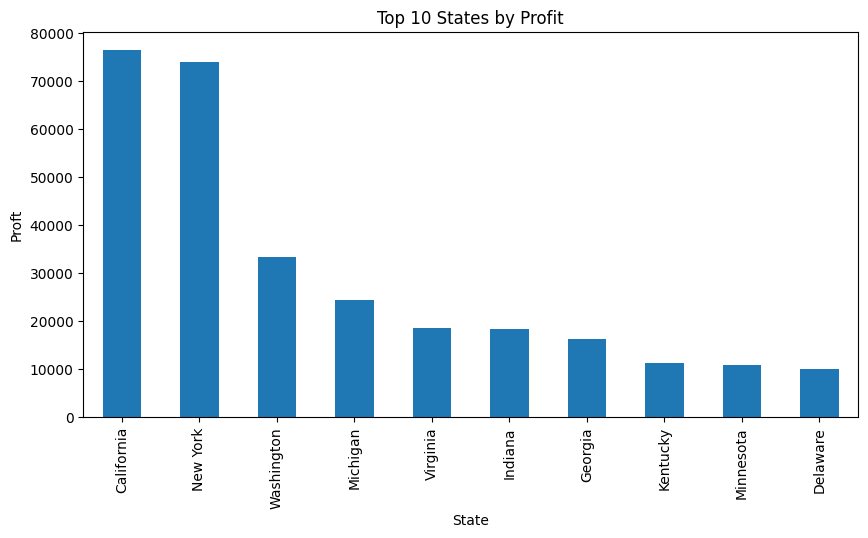

In [20]:
profit_by_state = df.groupby('State')['Profit'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
profit_by_state.plot(kind='bar')
plt.title('Top 10 States by Profit')
plt.ylabel('Proft')
plt.show()

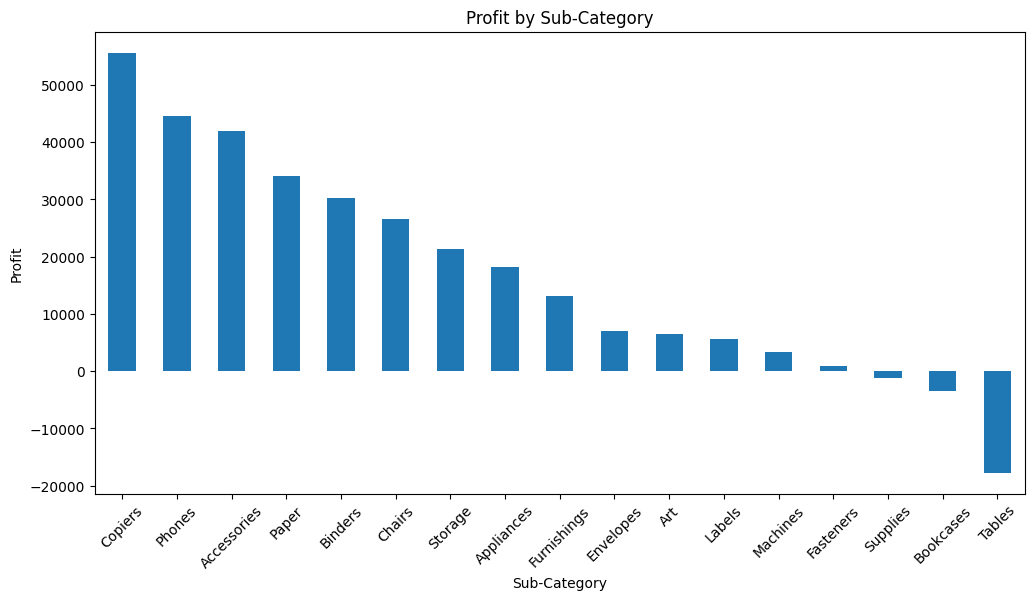

In [21]:
profit_by_subcategory = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
profit_by_subcategory.plot(kind='bar')
plt.title('Profit by Sub-Category')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.show()


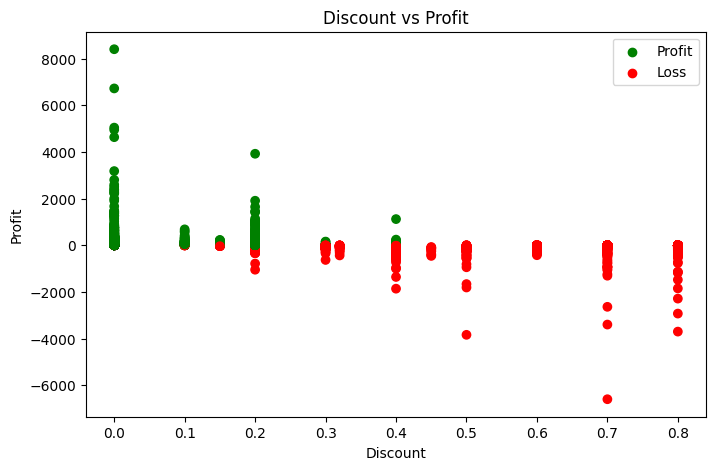

In [22]:
colors = ['green' if p > 0 else 'red' for p in df['Profit']]
plt.figure(figsize=(8,5))
plt.scatter(df['Discount'],df['Profit'],c=colors)
plt.scatter([], [], c='green',label='Profit')
plt.scatter([], [], c='red',label='Loss')
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.legend()
plt.show()

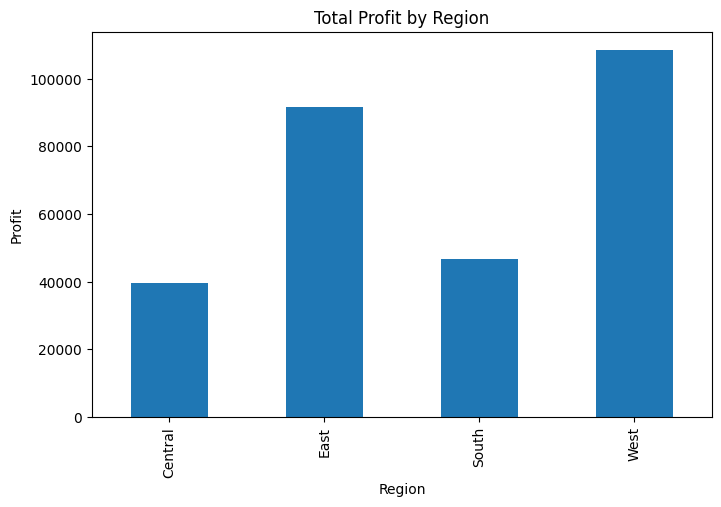

In [23]:
profit_by_region = df.groupby('Region')['Profit'].sum()
plt.figure(figsize=(8,5))
profit_by_region.plot(kind='bar')
plt.title('Total Profit by Region')
plt.ylabel('Profit')
plt.show()

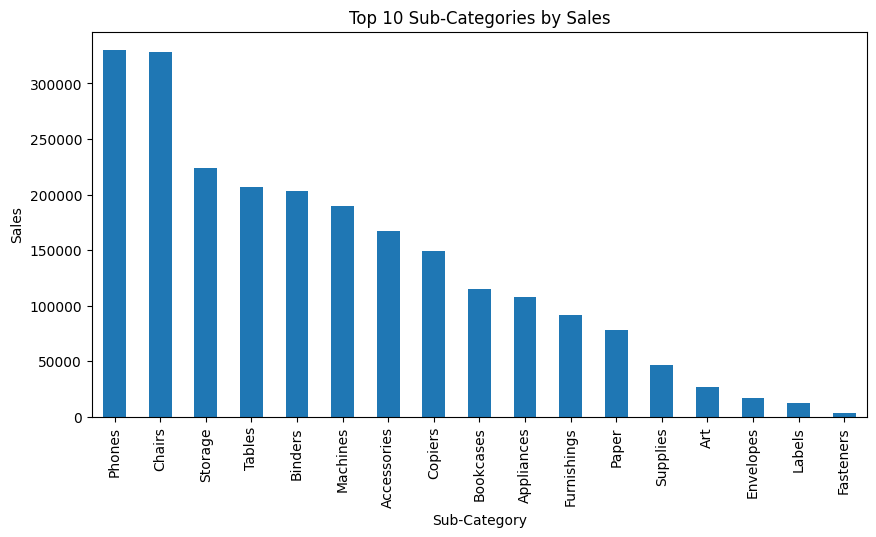

In [24]:
top_subcategories = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
top_subcategories.plot(kind='bar')
plt.title('Top 10 Sub-Categories by Sales')
plt.ylabel('Sales')
plt.show()


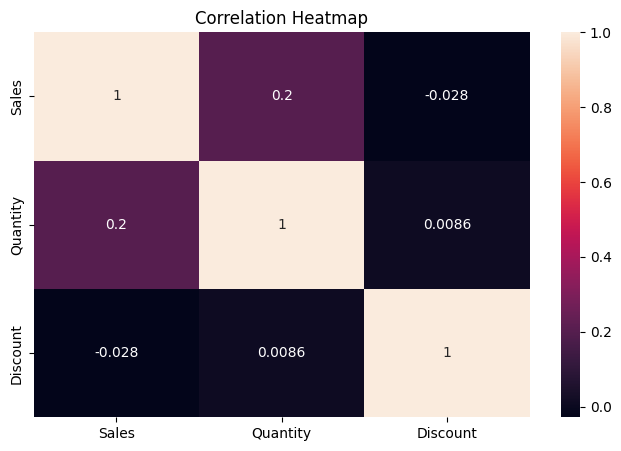

In [25]:
correlation = df[['Sales','Quantity','Discount']].corr()
plt.figure(figsize=(8,5))
sns.heatmap(correlation, annot=True)
plt.title('Correlation Heatmap')
plt.show()

## Key Findings
1. Technology generated the highest sales among all categories.
2. Copiers, Phones, and Accessories were the top-performing sub-categories by profit.
3. Tables showed negative profit, indicating losses despite generating sales.
4. The West region generated the highest sales and profit.
5. The Central region had the lowest overall business performance.
6. Higher discounts were often associated with lower profits and losses.
7. Sales and Profit showed a positive relationship, while Discount negatively impacted Profit.